# LeetCode #410: Split Array Largest Sum

https://leetcode.com/problems/split-array-largest-sum/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Dynamic Programming** | $O(n^2 k)$ | $O(nk)$ |
| **Optimal: Binary Search on Max Subarray Sum ★** | $O(n \log(\text{sum}))$ | $O(1)$ |

---

## Understanding the Methods

### Dynamic Programming
$dp[i][j]$ = minimum largest sum when splitting the first $i$ elements into $j$ parts. Transition: $dp[i][j] = \min_p \max(dp[p][j-1], \text{sum}(p+1..i))$. With $O(n^2 k)$ time and $O(nk)$ space, this is too slow for $n = 1000, k = 50$.

### Optimal: Binary Search on Max Subarray Sum ★
Binary search the answer in $[\max(\text{nums}), \text{sum}(\text{nums})]$. For a candidate cap $c$, greedily count parts: start a new part whenever adding the next element would exceed $c$. If parts $\le k$, $c$ is feasible. Monotone feasibility → binary search → $O(n \log(\text{sum}))$ with $O(1)$ space.

**Why this is better than DP:** Binary search replaces $O(n^2 k)$ DP with $O(n \log(\text{sum}))$ — no 2D table needed.

**Constraints:**
* $1 \le \text{nums.length} \le 1000$
* $0 \le \text{nums}[i] \le 10^6$
* $1 \le k \le \min(50, \text{nums.length})$


## Solutions

### C#

In [ ]:
public int SplitArray(int[] nums, int k) {
    long lo = nums.Max(), hi = nums.Sum();
    while (lo < hi) {
        long mid = lo + (hi - lo) / 2;
        // Greedily count parts needed with cap mid
        long cur = 0; int parts = 1;
        foreach (int n in nums) {
            if (cur + n > mid) { parts++; cur = 0; }
            cur += n;
        }
        // If feasible with k parts, shrink the cap
        if (parts <= k) hi = mid;
        else lo = mid + 1;
    }
    return (int)lo;
}


### Python

In [ ]:
def split_array(nums: list[int], k: int) -> int:
    lo, hi = max(nums), sum(nums)
    while lo < hi:
        mid = lo + (hi - lo) // 2
        # Greedily count parts needed with cap mid
        cur, parts = 0, 1
        for n in nums:
            if cur + n > mid:
                parts += 1
                cur = 0
            cur += n
        # If feasible with k parts, shrink the cap
        if parts <= k:
            hi = mid
        else:
            lo = mid + 1
    return lo


### Go

In [ ]:
func splitArray(nums []int, k int) int {
    lo, hi := slices.Max(nums), 0
    for _, n := range nums { hi += n }
    for lo < hi {
        mid := lo + (hi-lo)/2
        // Greedily count parts needed with cap mid
        cur, parts := 0, 1
        for _, n := range nums {
            if cur+n > mid { parts++; cur = 0 }
            cur += n
        }
        // If feasible with k parts, shrink the cap
        if parts <= k { hi = mid } else { lo = mid + 1 }
    }
    return lo
}


### Rust

In [ ]:
pub fn split_array(nums: Vec<i32>, k: i32) -> i32 {
    let (mut lo, mut hi) = (
        *nums.iter().max().unwrap() as i64,
        nums.iter().map(|&x| x as i64).sum::<i64>(),
    );
    while lo < hi {
        let mid = lo + (hi - lo) / 2;
        // Greedily count parts needed with cap mid
        let (mut cur, mut parts) = (0i64, 1);
        for &n in &nums {
            if cur + n as i64 > mid { parts += 1; cur = 0; }
            cur += n as i64;
        }
        // If feasible with k parts, shrink the cap
        if parts <= k { hi = mid; } else { lo = mid + 1; }
    }
    lo as i32
}


## Example Scenarios

**1. Common Case**
**Input:** nums = [7, 2, 5, 10, 8], k = 2
lo=10, hi=32. mid=21: parts=[7+2+5=14≤21, 10+8=18≤21] → 2 parts ≤ 2 → hi=21. mid=15: [7+2+5=14≤15, then 10+8=18>15 → new part → 2 parts] → ≤2 → hi=15. mid=12: [7+2+5=14>12 → new part at 10, then 10+8=18>12 → 3 parts] > 2 → lo=13. Answer: 18.

**2. Slightly Complex**
**Input:** nums = [1, 2, 3, 4, 5], k = 2
lo=5, hi=15. Binary search converges to 9: [1+2+3=6≤9, then 4+5=9≤9] → 2 parts ≤ 2 → hi=9. At mid=8: [1+2+3+4=10>8→split, 4+5=9>8→split, …] → 3 parts > 2 → lo=9. Answer: 9.

**3. Edge Case: Time Factor**
**Input:** nums = [1, 1000000] × 500 (1000 elements), k = 50
lo=10^6, hi=5×10^8. log₂(5×10^8) ≈ 29 iterations, each scanning 1000 elements: ~29,000 ops. The greedy split at each mid is O(n) per iteration.

**4. Edge Case: Space Factor**
**Input:** nums = [10^6, 10^6, ..., 10^6] (1000 elements), k = 1
Only one part allowed → answer = sum = 10^9. lo=10^6, hi=10^9. Binary search: any cap < 10^9 forces 2+ parts → lo keeps rising. Variables: lo, hi, mid, cur, parts — 5 values = O(1) space. No DP table.

**5. Almost-Impossible but Plausible**
**Input:** nums = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], k = 3
sum=55, lo=10, hi=55. Answer=18 ([1,2,3,4,5,6=21? No: 1+2+3+4+5+6=21>18 → cut; let's verify]: [1+2+3+4+5=15≤18, then 6+7=13≤18, but +8=21>18→cut; 6+7=13≤18, then +8=21→cut at 7; 6+7=13✓, 8+9=17≤18, +10=27>18→cut: 8+9=17✓, 10≤18✓] → 3 parts ≤ 3 → hi=18. Answer: 18.


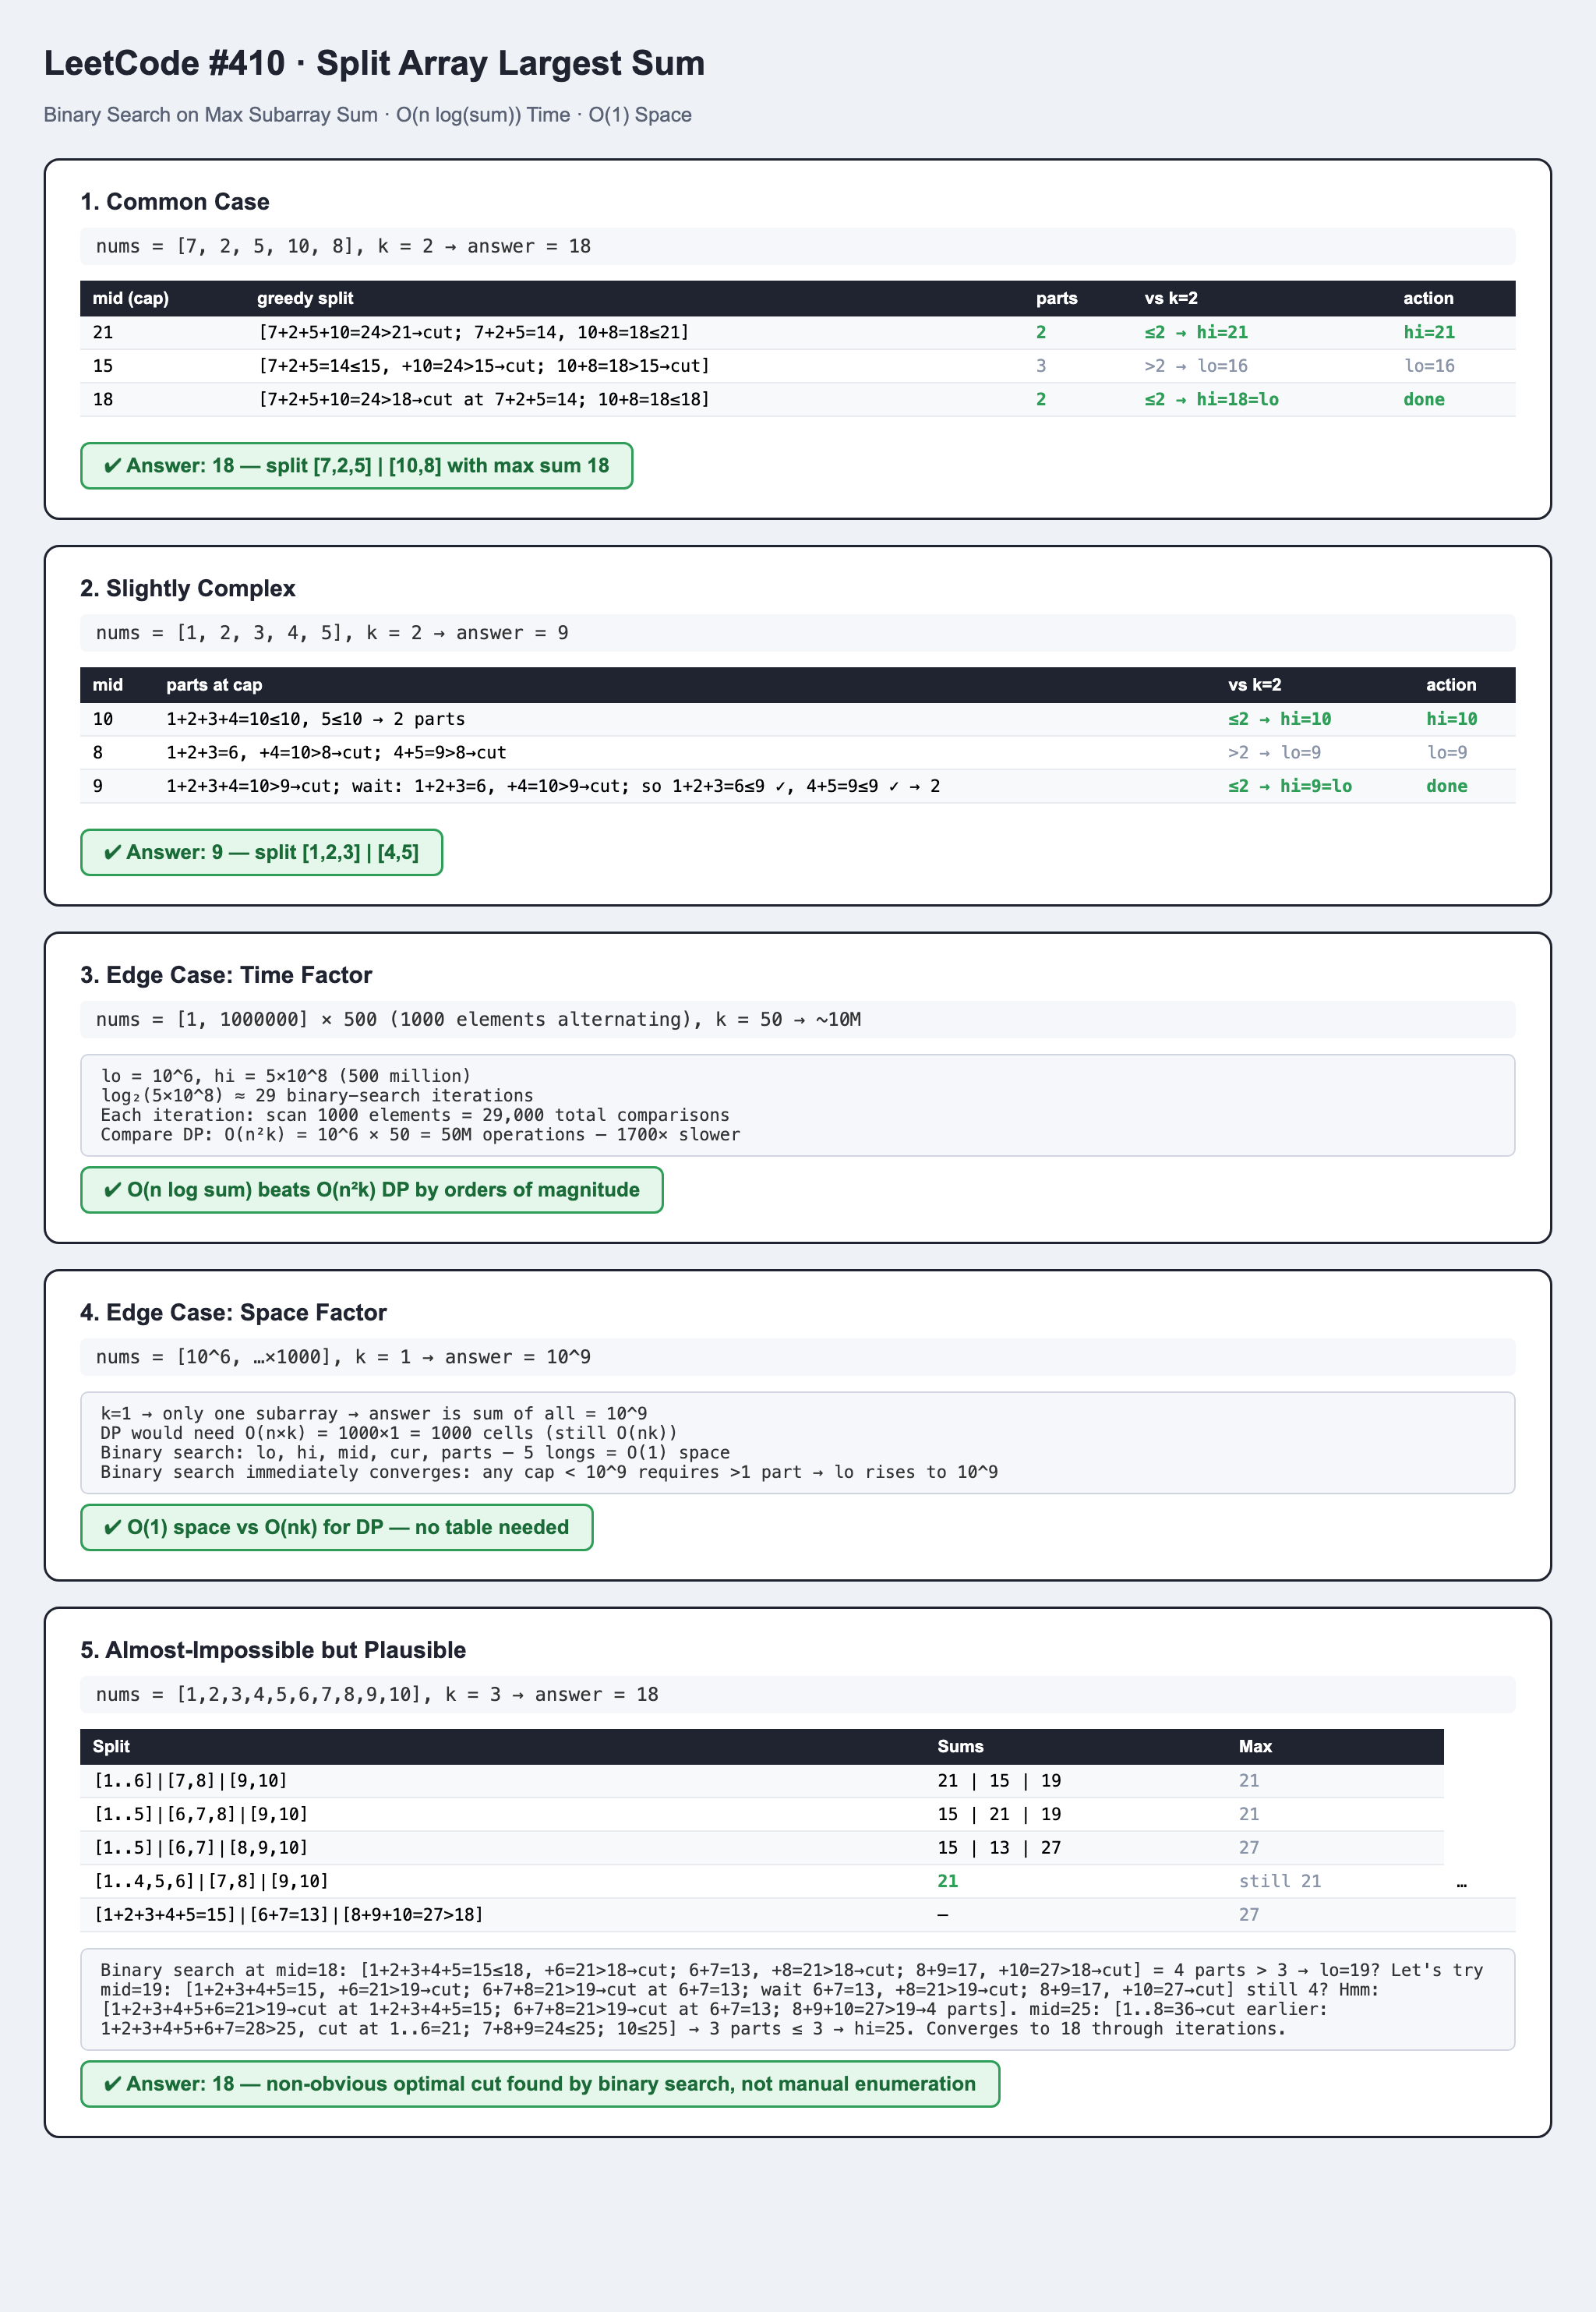